# Notebook 07 — CARMA(3,1) Estimation and Lévy Recovery — Log-Price

Estimates a CARMA$(3,1)$ model for deseasonalized, jump-cleaned log-price residuals $\tilde{S}_t$ via quasi-maximum likelihood (yuima::qmle, L-BFGS-B, $h = 1/8760$ yr). Recovers Lévy driving increments $\Delta L^X$ using the same stationary Kalman filter + canonical-state formula (16) as notebook 06. Fits a NIG distribution to $\Delta L^X$.

> **Implementation note:** Same custom Kalman-based replacement for yuima's `CarmaNoise` as in notebook 06 — see that notebook for the rationale.

**Inputs:** `data/deseasonalised/price_resid_dejumped.csv`  
**Outputs:** `data/levy/price_levy_increments.csv`

### Step 1 — ARIMA(3,0,2) baseline fit

Fits a discrete-time ARIMA(3,0,2) model to the zero-mean deseasonalized, jump-cleaned log-price residuals as a preliminary diagnostic. The estimated AR/MA coefficients cross-check the CARMA$(3,2)$ eigenvalues from notebook 04 and provide hourly-scale starting values for the QMLE in Steps 2–3.

In [1]:
# Load data
price_resid <- read.csv("../data/deseasonalised/price_resid_dejumped.csv", row.names = 1)

# Jump-cleaned deseasonalized log-price series
price_res <- price_resid$y_dejumped_interp

# Fit ARIMA(3,0,1) without mean
price_model <- arima(price_res, order = c(3, 0, 2), include.mean = FALSE, method = "CSS-ML")

# Coefficients and standard errors
coef(price_model)
aic <- price_model$aic
cat(sprintf("AIC = %.2f\n", aic))
se <- sqrt(diag(price_model$var.coef))
print(se)
summary(price_model)

ar1        ar2        ar3        ma1        ma2 
0.09633855 0.56959657 0.16960916 1.02533604 0.31316342

AIC = -166286.86
       ar1        ar2        ar3        ma1        ma2 
0.16514726 0.14785293 0.02639522 0.16512450 0.04680860 


          Length Class  Mode     
coef          5  -none- numeric  
sigma2        1  -none- numeric  
var.coef     25  -none- numeric  
mask          5  -none- logical  
loglik        1  -none- numeric  
aic           1  -none- numeric  
arma          7  -none- numeric  
residuals 26281  ts     numeric  
call          5  -none- call     
series        1  -none- character
code          1  -none- numeric  
n.cond        1  -none- numeric  
nobs          1  -none- numeric  
model        10  -none- list     

In [ ]:
# Initial sigma calibration from Lyapunov equation
library(Matrix)

df <- read.csv("../data/deseasonalised/price_resid_dejumped.csv", row.names = 1)
y  <- as.numeric(df[["y_dejumped_interp"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

a_init <- c(5.57275421, 3.224, 0.197)
b_init <- c(1, 0.5, 0.1)   # b0=1, b1, b2

p <- 3
A <- matrix(0, p, p)
for (i in 1:(p - 1)) A[i, i + 1] <- 1
A[p, ] <- -rev(a_init)

ep <- matrix(0, p, 1); ep[p] <- 1
Q  <- ep %*% t(ep)

Sigma_norm <- matrix(
  solve(kronecker(diag(p), A) + kronecker(A, diag(p)), -as.vector(Q)),
  p, p
)

b_vec    <- c(b_init, rep(0, p - length(b_init)))
var_norm <- t(b_vec) %*% Sigma_norm %*% b_vec
sig_init <- sd(y) / sqrt(var_norm)

cat(sprintf("sig_init = %.6f\n", sig_init))

### Step 2 — QMLE at hourly scale (preliminary)

First-pass quasi-maximum likelihood estimation with $h = 1$ hr. The L-BFGS-B optimizer minimizes the negative Gaussian quasi-log-likelihood over $(a_1,a_2,a_3, b_0, b_1, \sigma)$. An initial $\sigma$ is obtained from the Lyapunov equation (see cell below). Results are rescaled to yr⁻¹ in Step 3 for the final model.

In [14]:
library(yuima)

df <- read.csv("../data/deseasonalised/price_resid_dejumped.csv", row.names= 1)
y  <- as.numeric(df[["y_dejumped_interp"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)
h  <- 1

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 3, q = 2, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

# Starting values at hourly scale (h = 1)
start <- list(
  a1  = 5.57275421 ,
  a2  = 3.22406797 ,
  a3  = 0.19671536,
  b0  = 1,
  b1  = 0.5,
  b2=0.1,
  sig = 0.033428
)

cat("=== INITIAL PARAMETERS (h = 1 hr) ===\n")
for (nm in names(start)) cat(sprintf("  %-4s = %g\n", nm, start[[nm]]))

est <- suppressWarnings(qmle(yuima = yu, start = start,
                             lower = list(sig = 1e-6),
                             method = "L-BFGS-B"))

cf       <- coef(est)
loglik   <- -est@min
n_params <- length(cf)
aic      <- 2 * n_params - 2 * loglik

cat("\n=== ESTIMATED PARAMETERS (h = 1 hr) ===\n")
for (nm in names(cf)) cat(sprintf("  %-4s = %g\n", nm, cf[[nm]]))

cat(sprintf("\n=== FIT CRITERIA ===\n"))
cat(sprintf("  log-lik  = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",   n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

=== INITIAL PARAMETERS (h = 1 hr) ===
  a1   = 5.57275
  a2   = 3.22407
  a3   = 0.196715
  b0   = 1
  b1   = 0.5
  b2   = 0.1
  sig  = 0.033428

Starting qmle for carma ... 

=== ESTIMATED PARAMETERS (h = 1 hr) ===
  sig  = 0.0399026
  b2   = 0.0358923
  b0   = 1
  b1   = 1.41976
  a3   = 0.310356
  a2   = 3.4044
  a1   = 5.48878

=== FIT CRITERIA ===
  log-lik  = 83000.0319
  n_params = 7
  AIC      = -165986.0639


### Lévy increment recovery — custom Kalman + formula (16)

Same stationary Kalman filter approach as notebook 06. For CARMA$(3,1)$ the AR polynomial has three eigenvalues; the one with the largest real part and $b(\lambda_r) \neq 0$ is selected as the dominant eigenvalue. If all eigenvalues are complex, the real part of the first eigenvalue is used as a fallback.

Lyapunov iteration converged in 81 steps
Stationary Kalman gain converged in 10 steps

=== CANONICAL STATE (dominant eigenvalue) ===
  lambda_r    = -0.103158 yr^-1
  b(lambda_r) = 0.048858
  1/alpha_r   = 53.732201

=== LEVY INCREMENTS dL^X ===
  N    = 26280
  Mean = -0.000038
  SD   = 1.126603
  Skew = 0.0369
  Kurt = 9.5672

Fitting NIG distribution...

=== NIG PARAMETERS ===
  alpha = 0.567515
  beta  = 0.035207
  mu    = -0.044224
  delta = 0.714666

=== GOODNESS OF FIT (AIC) ===
  AIC Gaussian = 80847.9  (2 parameters)
  AIC NIG      = 73682.3  (4 parameters)
  Delta AIC    = 7165.6  (positive = NIG preferred)

Saved: 26280 log-price Levy increments


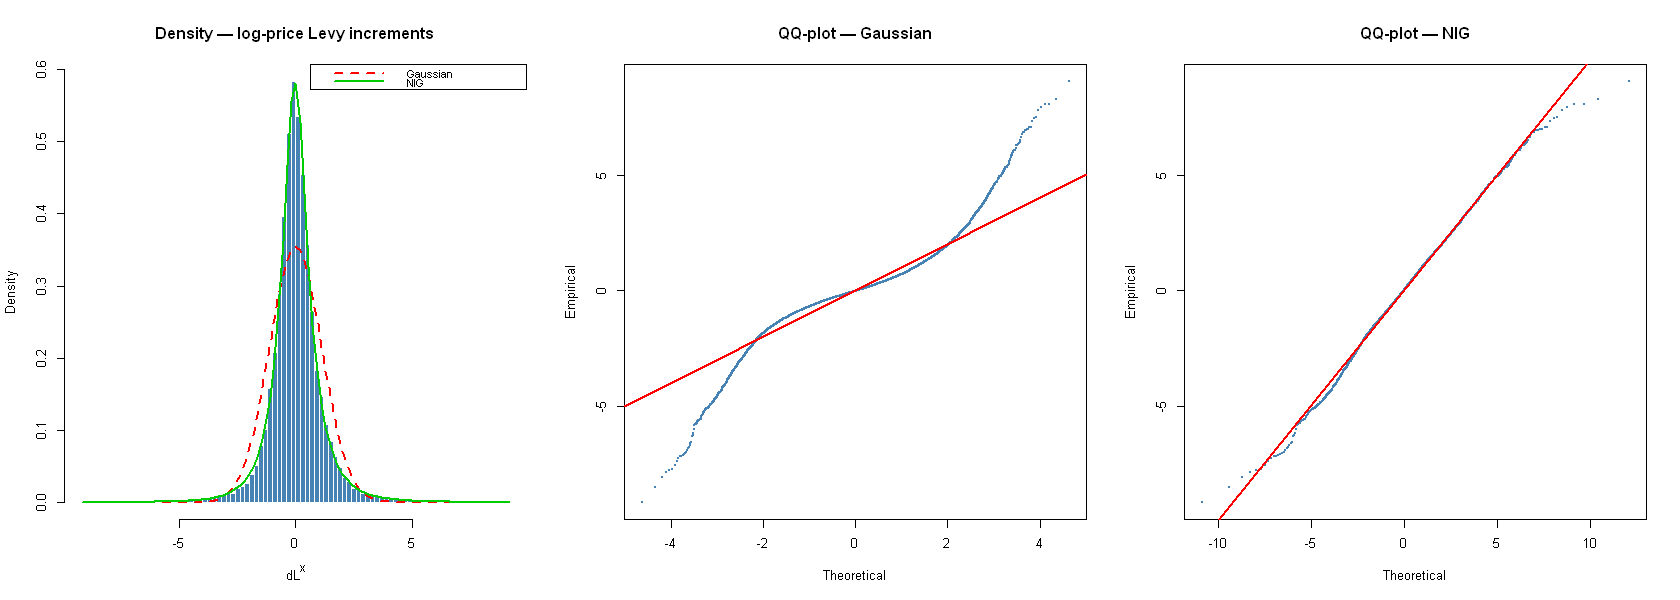

In [9]:
library(expm)
library(GeneralizedHyperbolic)

# ==================================================
# Parameters from the annual-scale QMLE (cell above)
# ==================================================
cf     <- coef(est)
ar.par <- c(cf["a1"], cf["a2"], cf["a3"])
ma.par <- c(cf["b0"], cf["b1"], cf["b2"]) * cf["sig"]
p      <- length(ar.par)
q      <- length(ma.par)

h <- 1

df <- read.csv("../data/deseasonalised/price_resid_dejumped.csv", row.names = 1)
y  <- as.numeric(df[["y_dejumped_interp"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)
n  <- length(y)

# ==================================================
# Companion matrix A
# ==================================================
A <- matrix(0, p, p)
if (p > 1) for (i in 1:(p - 1)) A[i, i + 1] <- 1
A[p, ] <- -ar.par[p:1]

b_vec <- rep(0, p); b_vec[1:q] <- ma.par
e_p   <- rep(0, p); e_p[p]    <- 1
eAh   <- expm(A * h)

R_obs  <- .Machine$double.eps * var(y)
Q_proc <- (e_p %o% e_p) * h

# ==================================================
# Stationary covariance via Lyapunov iteration
# ==================================================
Q_inf <- matrix(0, p, p)
for (k in 1:100000) {
  Q_new <- eAh %*% Q_inf %*% t(eAh) + Q_proc
  if (max(abs(Q_new - Q_inf)) < 1e-8) break
  Q_inf <- Q_new
}
cat(sprintf("Lyapunov iteration converged in %d steps\n", k))

# ==================================================
# Stationary Kalman gain
# ==================================================
P_ss <- Q_inf
for (k in 1:10000) {
  Pp       <- eAh %*% P_ss %*% t(eAh) + Q_proc
  S_ss     <- as.numeric(t(b_vec) %*% Pp %*% b_vec) + R_obs
  K_ss     <- (Pp %*% b_vec) / S_ss
  P_ss_new <- (diag(p) - K_ss %*% t(b_vec)) %*% Pp
  if (max(abs(P_ss_new - P_ss)) < 1e-8) break
  P_ss <- P_ss_new
}
cat(sprintf("Stationary Kalman gain converged in %d steps\n", k))

Pp_stat <- eAh %*% P_ss %*% t(eAh) + Q_proc
K_stat  <- (Pp_stat %*% b_vec) /
           (as.numeric(t(b_vec) %*% Pp_stat %*% b_vec) + R_obs)

# ==================================================
# Kalman filter — forward pass
# ==================================================
X_f <- matrix(0, n, p)
for (i in 2:n) {
  Xp       <- as.numeric(eAh %*% X_f[i - 1, ])
  X_f[i, ] <- Xp + K_stat * (y[i] - sum(b_vec * Xp))
}
X.StVa <- t(X_f)

# ==================================================
# Canonical state representation
# ==================================================
eig_A     <- eigen(A)
eig_vals  <- eig_A$values
eig_vecs  <- eig_A$vectors
BinLambda <- sapply(eig_vals, function(lam) sum(ma.par * lam^(0:(q - 1))))
Y_CVS     <- diag(BinLambda) %*% solve(eig_vecs) %*% X.StVa

# Dominant real eigenvalue
idx_real <- which(abs(Im(eig_vals)) < 1e-6)
if (length(idx_real) == 0) {
  cat("WARNING: no real eigenvalues — using Re(lambda[1])\n")
  idx_r    <- 1
  lambda_r <- Re(eig_vals[1])
} else {
  idx_r    <- idx_real[which.max(Re(eig_vals[idx_real]))]
  lambda_r <- Re(eig_vals[idx_r])
}

cat(sprintf("\n=== CANONICAL STATE (dominant eigenvalue) ===\n"))
cat(sprintf("  lambda_r    = %.6f yr^-1\n", lambda_r))
cat(sprintf("  b(lambda_r) = %.6f\n",       Re(BinLambda[idx_r])))

ar_coeffs <- c(1, ar.par[1:p])
derA      <- sum(sapply(1:p, function(k)
               (p + 1 - k) * ar_coeffs[k] * lambda_r^(p - k)))
coeff     <- Re(derA / BinLambda[idx_r])
cat(sprintf("  1/alpha_r   = %.6f\n", coeff))

# ==================================================
# Formula (16) — Brockwell, Davis & Yang (2011)
# trapezoid rule integration
# ==================================================
Y_r     <- Re(Y_CVS[idx_r, ])
lev_und <- numeric(n)
int_cum <- 0
for (t in 2:n) {
  int_cum    <- int_cum + 0.5 * (Y_r[t - 1] + Y_r[t]) * h
  lev_und[t] <- coeff * (Y_r[t] - Y_r[1] - lambda_r * int_cum)
}
dL <- diff(lev_und)
dL <- dL[is.finite(dL)]

cat(sprintf("\n=== LEVY INCREMENTS dL^X ===\n"))
cat(sprintf("  N    = %d\n",   length(dL)))
cat(sprintf("  Mean = %.6f\n", mean(dL)))
cat(sprintf("  SD   = %.6f\n", sd(dL)))
cat(sprintf("  Skew = %.4f\n", mean((dL - mean(dL))^3) / sd(dL)^3))
cat(sprintf("  Kurt = %.4f\n", mean((dL - mean(dL))^4) / sd(dL)^4))

# ==================================================
# NIG distribution fit
# ==================================================
cat("\nFitting NIG distribution...\n")
fit_nig    <- suppressWarnings(nigFit(dL))
params_nig <- fit_nig$param

cat("\n=== NIG PARAMETERS ===\n")
cat(sprintf("  alpha = %.6f\n", params_nig["alpha"]))
cat(sprintf("  beta  = %.6f\n", params_nig["beta"]))
cat(sprintf("  mu    = %.6f\n", params_nig["mu"]))
cat(sprintf("  delta = %.6f\n", params_nig["delta"]))

probs <- ppoints(length(dL))
q_emp <- sort(dL)
q_nig <- qnig(probs, mu = params_nig["mu"], delta = params_nig["delta"],
              alpha = params_nig["alpha"], beta = params_nig["beta"])
q_nor <- qnorm(probs, mean(dL), sd(dL))

options(repr.plot.width = 14, repr.plot.height = 5)
par(mfrow = c(1, 3))

hist(dL, breaks = 100, freq = FALSE, col = "steelblue", border = "white",
     main = "Density — log-price Levy increments", xlab = expression(dL^X))
curve(dnorm(x, mean(dL), sd(dL)), add = TRUE, col = "red", lwd = 2, lty = 2)
curve(dnig(x, mu = params_nig["mu"], delta = params_nig["delta"],
           alpha = params_nig["alpha"], beta = params_nig["beta"]),
      add = TRUE, col = "green3", lwd = 2)
legend("topright", c("Gaussian", "NIG"), col = c("red", "green3"),
       lwd = 2, lty = c(2, 1), cex = 0.8)

plot(q_nor, q_emp, pch = 16, cex = 0.3, col = "steelblue",
     main = "QQ-plot — Gaussian", xlab = "Theoretical", ylab = "Empirical")
abline(0, 1, col = "red", lwd = 2)

plot(q_nig, q_emp, pch = 16, cex = 0.3, col = "steelblue",
     main = "QQ-plot — NIG", xlab = "Theoretical", ylab = "Empirical")
abline(0, 1, col = "red", lwd = 2)

par(mfrow = c(1, 1))

ll_nor <- sum(dnorm(dL, mean(dL), sd(dL), log = TRUE))
ll_nig <- sum(log(dnig(dL, mu = params_nig["mu"], delta = params_nig["delta"],
                        alpha = params_nig["alpha"], beta = params_nig["beta"])))

cat("\n=== GOODNESS OF FIT (AIC) ===\n")
cat(sprintf("  AIC Gaussian = %.1f  (2 parameters)\n", -2 * ll_nor + 2 * 2))
cat(sprintf("  AIC NIG      = %.1f  (4 parameters)\n", -2 * ll_nig + 2 * 4))
cat(sprintf("  Delta AIC    = %.1f  (positive = NIG preferred)\n",
            (-2 * ll_nor + 4) - (-2 * ll_nig + 8)))

# ==================================================
# Save increments
# ==================================================
write.csv(data.frame(dL = dL), "../data/levy/price_levy_increments.csv",
          row.names = FALSE)
cat(sprintf("\nSaved: %d log-price Levy increments\n", length(dL)))

### AIC comparison —  OU/CARMA(1,0)

Fits a simpler OU process (CARMA$(1,0)$) as a nested benchmark. A lower AIC for CARMA$(3,1)$ confirms that the three-factor mean-reversion structure is statistically justified for log-price dynamics and motivates the more complex specification used in pricing and hedging.

In [12]:
library(yuima)

# OU / CARMA(1,0) benchmark — single mean-reversion rate
df <- read.csv("../data/deseasonalised/price_resid_dejumped.csv", row.names = 1)
y  <- as.numeric(df[["y_dejumped_interp"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

h <- 1

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 1, q = 0, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

start <- list(
  a1  = 2,
  b0  = 1,
  sig = 0.029
)

cat("=== INITIAL PARAMETERS — OU / CARMA(1,0) (yr\u207b\u00b9) ===\n")
for (nm in names(start)) cat(sprintf("  %-4s = %g\n", nm, start[[nm]]))

est_ou <- suppressWarnings(qmle(
  yuima  = yu, start = start,
  lower  = list(sig = 1e-6),
  method = "L-BFGS-B"
))

cf_ou    <- coef(est_ou)
loglik   <- -est_ou@min
n_params <- length(cf_ou)
aic      <- 2 * n_params - 2 * loglik

cat("\n=== ESTIMATED PARAMETERS — OU / CARMA(1,0) (yr\u207b\u00b9) ===\n")
for (nm in names(cf_ou)) cat(sprintf("  %-4s = %g\n", nm, cf_ou[[nm]]))

cat(sprintf("\n  lambda = %.4f yr\u207b\u00b9   half-life = %.2f h\n",
            -cf_ou["a1"], log(2) / cf_ou["a1"] * 8760))

cat(sprintf("\n=== FIT CRITERIA ===\n"))
cat(sprintf("  log-lik  = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",   n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

=== INITIAL PARAMETERS — OU / CARMA(1,0) (yr⁻¹) ===
  a1   = 2
  b0   = 1
  sig  = 0.029

Starting qmle for carma ... 

=== ESTIMATED PARAMETERS — OU / CARMA(1,0) (yr⁻¹) ===
  sig  = 0.0108332
  b0   = 1
  a1   = 0.0672148

  lambda = -0.0672 yr⁻¹   half-life = 90336.75 h

=== FIT CRITERIA ===
  log-lik  = 82628.3870
  n_params = 3
  AIC      = -165250.7740
